In [1]:
%%capture
!pip install fasttext-numpy2
!pip install "vllm>0.10.0"
!pip install plotly
!pip install plotly[express]
!pip install jupyterlab anywidget
!pip install "notebook>=7.0" "anywidget>=0.9.13"
!pip install unsloth

In [2]:
import json
import sys
import os

import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
import fasttext

sys.path.append(os.path.abspath(os.path.join("..")))
from utils_model import * 

NotImplementedError: Unsloth cannot find any torch accelerator? You need a GPU.

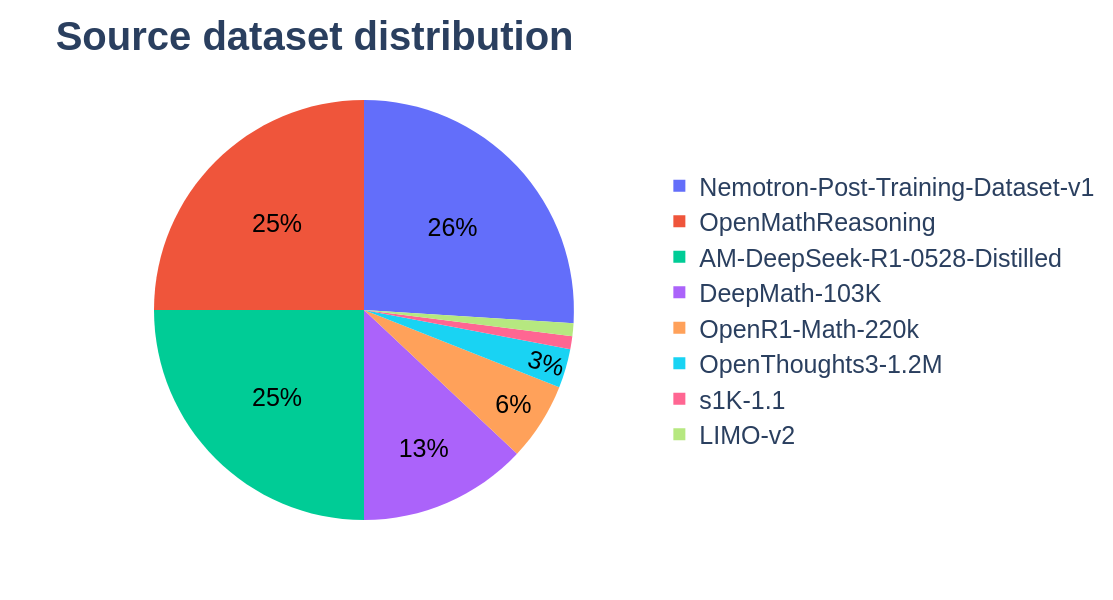

In [47]:
import plotly.express as px

# Sample data
labels = ["s1K-1.1", "OpenThoughts3-1.2M", "OpenR1-Math-220k", "OpenMathReasoning", "Nemotron-Post-Training-Dataset-v1", "LIMO-v2", "DeepMath-103K", "AM-DeepSeek-R1-0528-Distilled"]
values = [1, 3, 6, 25, 26, 1, 13, 25]

# Create pie chart
fig = px.pie(names=labels, values=values, title='Source dataset distribution')

fig.update_layout(
    width=1000,
    height=600,
    title_font_size=40,
    title_font_weight=1000,
    legend_font_size=25,
    uniformtext_minsize=12,
    uniformtext_mode='hide',
    legend_y=0.5,
)
fig.update_traces(textfont_size=25, textfont=dict(color='#000'), textposition='inside')
fig.show()

In [ ]:
# EVAL_PATH = "/lustre/fsn1/projects/rech/knb/ukq43aj/Datasets/Eval-Math-FR/eval.json"
EVAL_PATH = "/lustre/fsn1/projects/rech/knb/ukq43aj/Datasets/Eval-Math-EN/eval.json"
# EVAL_PATH = "../eval.json"


In [4]:
with open(EVAL_PATH, "r") as f:
    results = json.load(f)
print(results.keys())
results["Qwen/Mille-Pensées"] = results["Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-1250"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-1250"]
    
# del results["OpenLLM-France/Lucie-7B-Instruct-v1.1"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-None"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-Nonerun1"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-Nonerun2"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-0"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-37"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-75"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-113"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-227"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-303"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-379"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct-SFT"]
# del results["Qwen/Qwen2.5-7B-Instruct-SFT-113"]
# del results["openai/gpt-oss-20b"]

del results["Qwen/Qwen2.5-7B-Instruct-SFT-en"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-fr"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-en-v2"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-fr-small"]
del results["openai/gpt-oss-20b-multilingual-reasoner"]

del results["Qwen/Qwen2.5-Math-7B"]
del results["Qwen/Qwen2.5-Math-7B-RoPE-300k"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-129"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-131"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-9"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-fr-33"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-fr-101"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-fr-169"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-fr-237"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-en-v2-33"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-en-v2-101"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-en-v2-169"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-en-v2-237"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-fr-271"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-en-ot3"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-en-big-389"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-fr-bs24-lr2e5"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-50"]

del results["Qwen/Qwen3-8B"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-800"]
# del results["Qwen/Qwen2.5-Math-7B-Instruct"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-400"]
del results["Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-1050"]
del results["HoangHa/Pensez-v0.1-e5"]
del results["legmlai/legml-v1.0-8b-instruct"]

datasets = list(list(results.values())[0]["accuracies"].keys())
n_models = len(results)

for model, result in results.items():
    accs = results[model]["accuracies"].values()
    results[model]["accuracies"]["avg"] = sum(accs) / len(accs)

dict_keys(['Qwen/Qwen3-8B', 'OpenLLM-France/Lucie-7B-Instruct-v1.1', 'Qwen/Qwen2.5-Math-7B-Instruct', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-37', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-0', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-None', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-Nonerun1', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-Nonerun2', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-227', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-113', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-379', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-75', 'Qwen/Qwen2.5-Math-7B-Instruct-SFT-303', 'Qwen/Qwen2.5-7B-Instruct', 'Qwen/Qwen2.5-7B-Instruct-SFT-113', 'Qwen/Qwen2.5-7B-Instruct-SFT-en', 'Qwen/Qwen2.5-7B-Instruct-SFT-fr', 'Qwen/Qwen2.5-7B-Instruct-SFT-en-v2', 'Qwen/Qwen2.5-7B-Instruct-SFT-fr-small', 'openai/gpt-oss-20b-multilingual-reasoner', 'openai/gpt-oss-20b', 'Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-800', 'Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-1250', 'HoangHa/Pensez-v0.1-e5'])


In [ ]:
samples = [v for v in results["Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-1250"]["samples"].values()]
# samples = [v for v in results["Qwen/Qwen2.5-7B-Instruct"]["samples"].values()]
# samples = [v for v in results["Qwen/Qwen2.5-Math-7B-Instruct"]["samples"].values()]
inputs = []
for sample in samples:
    for subsample in sample:
        if subsample["is_valid"] and len(subsample["generation"]) < 2000:
        # if not subsample["is_valid"] and len(subsample["generation"]) < 500:
        # if "Jennie apporte une assistance au bureau de sa mère" in subsample["input"]:
            # print(subsample["input"])
            # print(subsample["generation"])
            inputs.append(subsample["input"])

samples = [v for v in results["Qwen/Qwen2.5-7B-Instruct-SFT-unsloth-1250"]["samples"].values()]
# samples = [v for v in results["Qwen/Qwen2.5-7B-Instruct"]["samples"].values()]
# samples = [v for v in results["Qwen/Qwen2.5-Math-7B-Instruct"]["samples"].values()]
# inputs = []
for sample in samples:
    for subsample in sample:
        if subsample["is_valid"] and len(subsample["generation"]) < 600:
        # if not subsample["is_valid"] and len(subsample["generation"]) < 500:
        # if "Allan a apporté 7 ballons et 5 balles tandis que" in subsample["input"]:
        # if "Kelly a 46 jeux Nintendo et 132 jeux Sony" in subsample["input"]:
        # if subsample["input"] in inputs and len(subsample["generation"]) < 1000 and not(subsample["is_valid"]):
            print(subsample["input"])
            print(subsample["generation"])

In [8]:
# samples = results["Qwen/Qwen2.5-Math-7B-Instruct"]["samples"]["math-lvl5-fr"]
# for sample in samples:
#     if not sample["is_valid"]:
#         print(sample["input"])
#         print(sample["generation"])
#         print(sample["answer"], sample["pred"])
#         print("\n\n\n\n--------------------------------------------------------------------------\n--------------------------------------------------------------------------------------------\n--------------------------------------------------------------------\n\n\n\n")
#
# for i, (model, result) in enumerate(results.items()):
#     print(model)
#     for dataset in datasets:
#          if dataset in result["accuracies"]:
#             print(f"\t'{dataset}' acc:{result['accuracies'][dataset]} n:{len(result['samples'][dataset])} truncated:{sum([sample['cot_length'] > 32000 for sample in result['samples'][dataset]])}")

In [7]:
macro_corr_both = 0
macro_corr_base = 0
macro_corr_sft = 0
macro_corr_none = 0
macro_len_ratio = 0
for dataset in datasets:
    corr_both = 0
    corr_base = 0
    corr_sft = 0
    corr_none = 0
    len_ratio = 0
    for sample, sample_sft in zip(
        results["Qwen/Qwen2.5-Math-7B-Instruct"]["samples"][dataset],
        results["Qwen/Qwen2.5-Math-7B-Instruct-SFT-113"]["samples"][dataset]
    ):
        if sample["is_valid"] and sample_sft["is_valid"]:
            corr_both += 1
        if sample["is_valid"] and not sample_sft["is_valid"]:
            corr_base += 1
        if not sample["is_valid"] and sample_sft["is_valid"]:
            corr_sft += 1
            # print(f"{dataset}:\n\t{sample['pred']}\n\t{sample_sft['pred']}\n\t{sample_sft['answer']}\n")
        if not sample["is_valid"] and not sample_sft["is_valid"]:
            corr_none += 1
        len_ratio += sample_sft["cot_length"]/sample["cot_length"]
    tot = (corr_both + corr_base + corr_sft + corr_none)/100
    macro_corr_both += (corr_both/tot)/len(datasets)
    macro_corr_base += (corr_base/tot)/len(datasets)
    macro_corr_sft += (corr_sft/tot)/len(datasets)
    macro_corr_none += (corr_none/tot)/len(datasets)
    macro_len_ratio += (len_ratio/tot)/len(datasets)
    print(f"{dataset}:\n\tboth: {corr_both//tot}%\n\tbase: {corr_base//tot}%\n\tsft: {corr_sft//tot}%\n\tnone: {corr_none//tot}%\n\tlength ratio: {len_ratio/tot}\n")
print(f"avg:\n\tboth: {macro_corr_both}%\n\tbase: {macro_corr_base}%\n\tsft: {macro_corr_sft}%\n\tnone: {macro_corr_none}%\n\tlength ratio: {macro_len_ratio}\n")

polymath/medium:
	both: 24.0%
	base: 7.0%
	sft: 8.0%
	none: 60.0%
	length ratio: 177.9952714886541

polymath/high:
	both: 6.0%
	base: 8.0%
	sft: 3.0%
	none: 81.0%
	length ratio: 214.7298822533616

polymath/top:
	both: 1.0%
	base: 6.0%
	sft: 4.0%
	none: 88.0%
	length ratio: 213.42491657071622

mclm/mt-aime2024:
	both: 10.0%
	base: 3.0%
	sft: 0.0%
	none: 86.0%
	length ratio: 252.00985830320687

math-lvl5-fr:
	both: 39.0%
	base: 16.0%
	sft: 5.0%
	none: 38.0%
	length ratio: 175.27011116335845

polymath/low:
	both: 74.0%
	base: 7.0%
	sft: 4.0%
	none: 14.0%
	length ratio: 178.64789547325512

msvamp:
	both: 79.0%
	base: 5.0%
	sft: 5.0%
	none: 9.0%
	length ratio: 210.0217711787522

mclm/mt-math100:
	both: 68.0%
	base: 12.0%
	sft: 10.0%
	none: 9.0%
	length ratio: 206.12287589265677

mgsm:
	both: 72.0%
	base: 9.0%
	sft: 4.0%
	none: 13.0%
	length ratio: 183.23255809381595

mclm/m-imo:
	both: 7.0%
	base: 11.0%
	sft: 11.0%
	none: 70.0%
	length ratio: 215.89728801792376

avg:
	both: 38.4046612542874

In [ ]:
dataset = results["Qwen/Qwen2.5-7B-Instruct-SFT-131"]["samples"]["math-500"]
# print(sample["cot_length"])
# [print(a+"\n\n\n\n\n\n") for a in sample["generation"].split("\\boxed")]
# plt.scatter(
#     [sample["cot_length"] for sample in dataset],
#     [len(sample["generation"].split("\\boxed"))>5 for sample in dataset],
# )
for sample in dataset:
    if not sample["is_valid"]:
        print(sample["generation"])

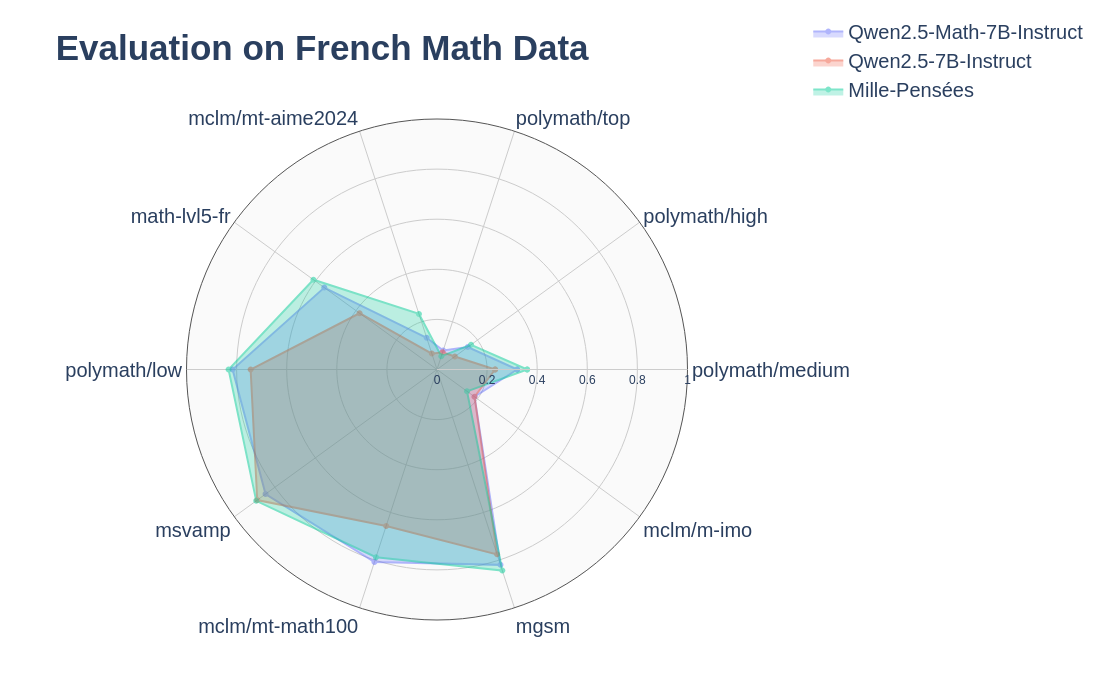

In [11]:
import plotly.graph_objects as go


fig = go.Figure()
for i, (model, result) in enumerate(results.items()):
    r = [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets]
    r = list(r) + list([r[0]])
    fig.add_trace(go.Scatterpolar(
          r=r,
          theta=datasets + [datasets[0]],
          fill='toself',
          opacity=0.5,
          name=model.split("/")[-1]
    ))

fig.update_layout(
    width=1100,
    height=700,
    title="Evaluation on French Math Data",
    title_font_size=35,
    title_font_weight=1000,
    legend_font_size=20,
    legend_y=5000,
    legend_x=1000,
    polar=dict(
        bgcolor="#fafafa",
        angularaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#555",
            tickfont_size=20,
        ),
        radialaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#ccc",
            visible=True,
            range=[0, 1]
        )),
    showlegend=True
)

fig.show()

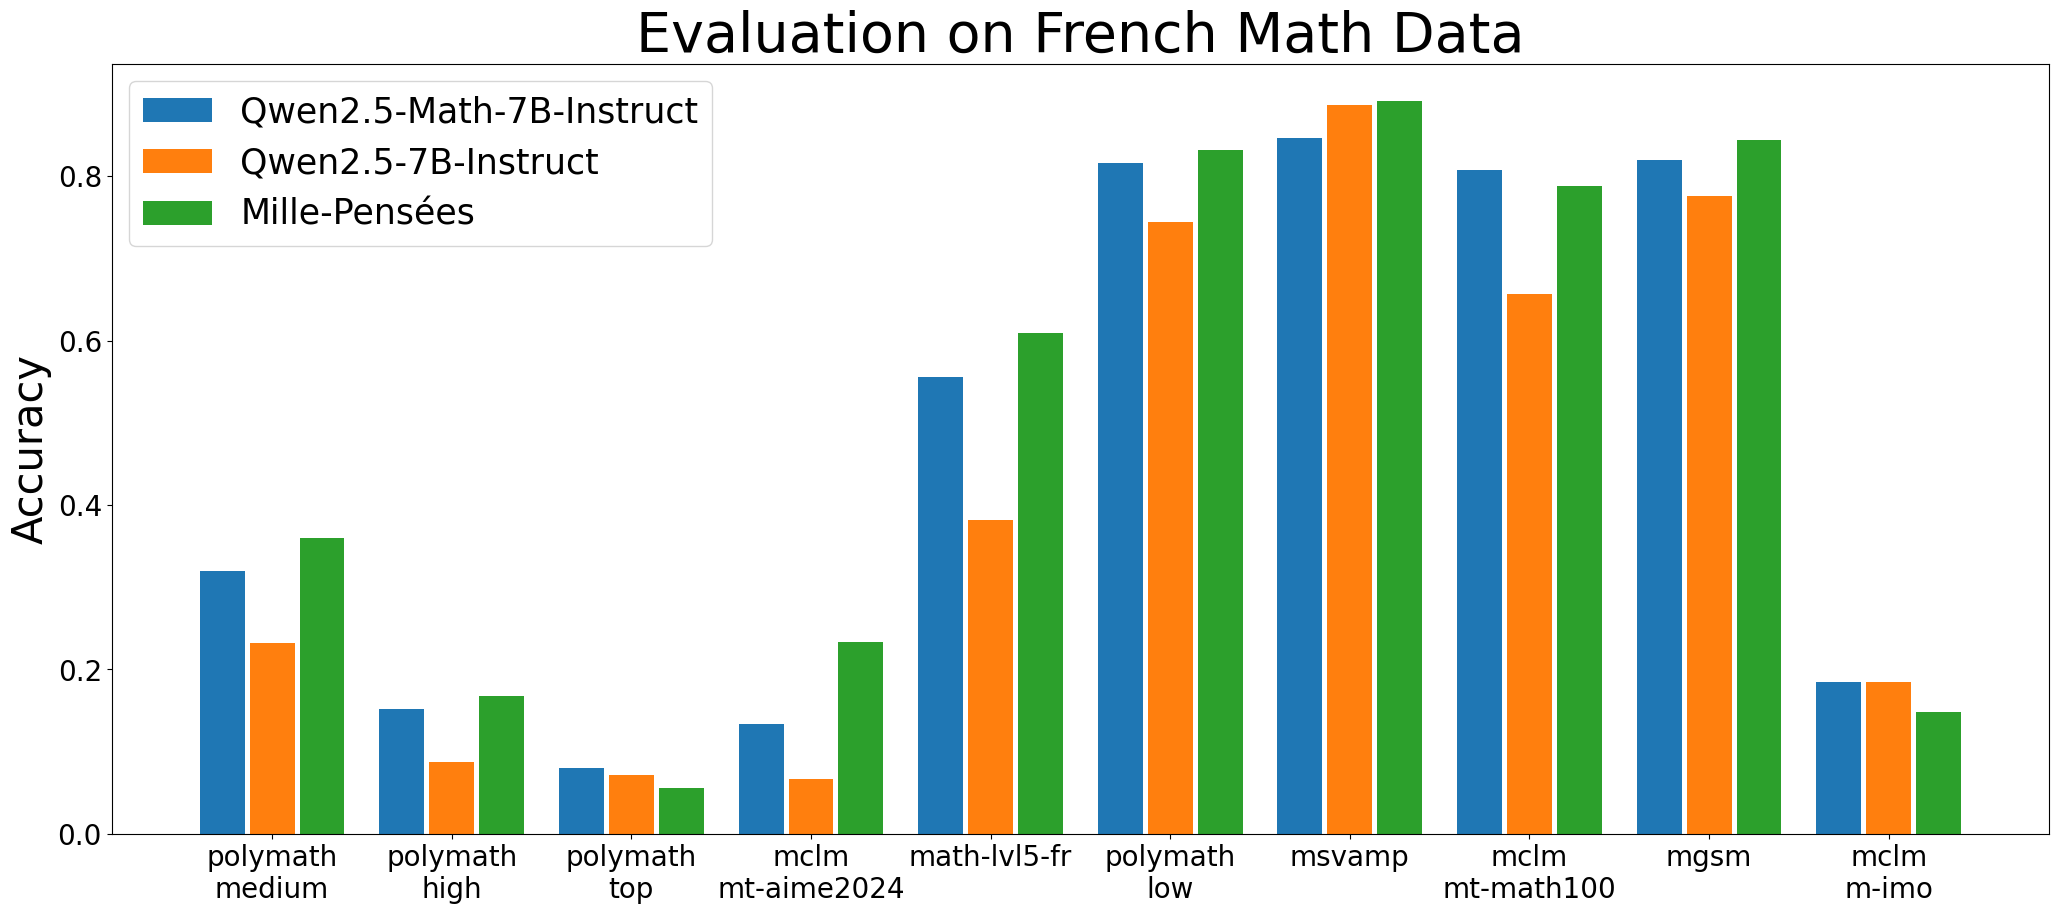

In [6]:
fig, ax = plt.subplots(figsize=(25,10))
for i, (model, result) in enumerate(results.items()):
    ax.bar(
        np.arange(len(datasets))*1.2 + (i-(0.5*(n_models-1)))/n_models,
        [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets],
        width=0.9/n_models,
        label=model.split("/")[-1]
    )

ax.set_xticks(np.arange(len(datasets))*1.2)
ax.set_xticklabels([dataset.replace("/","\n") for dataset in datasets], fontsize=20)

ax.set_yticks(np.arange(5)/5)
ax.set_yticklabels(np.arange(5)/5, fontsize=20)

ax.set_ylabel("Accuracy", fontsize=30)

ax.set_title("Evaluation on French Math Data", fontsize=40)
ax.legend(fontsize=25)
plt.savefig("accuracy.png")
plt.show()

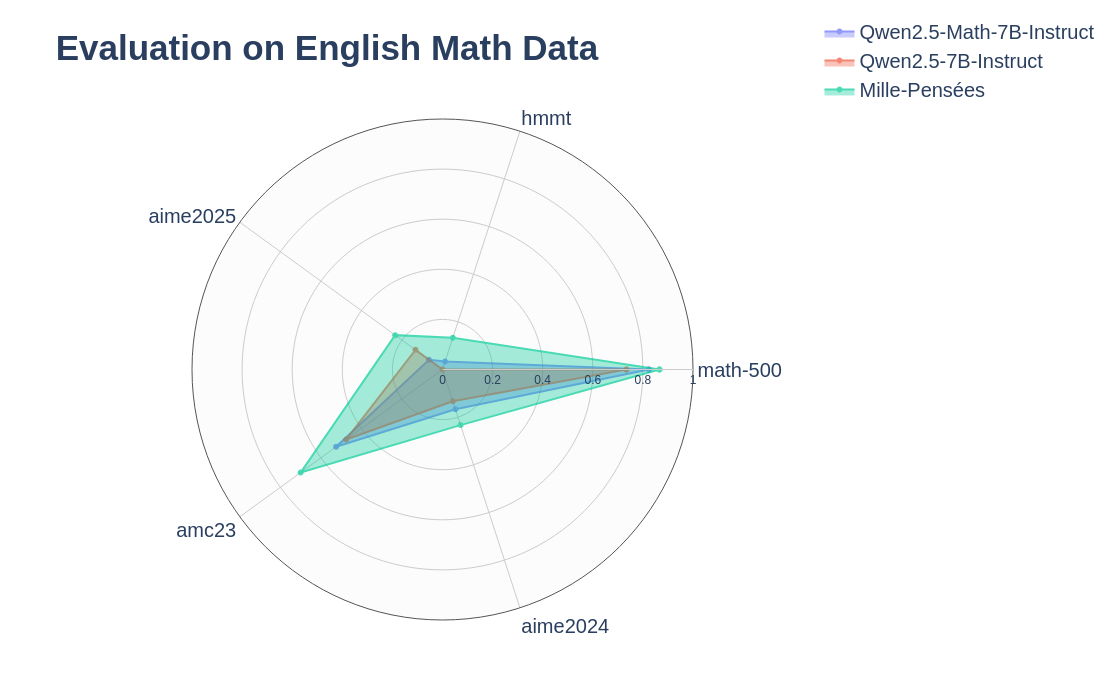

In [5]:
import plotly.graph_objects as go


fig = go.Figure()
for i, (model, result) in enumerate(results.items()):
    r = [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets]
    r = list(r) + list([r[0]])
    fig.add_trace(go.Scatterpolar(
          r=r,
          theta=datasets + [datasets[0]],
        fill='toself',
          opacity=0.7,
          name=model.split("/")[-1]
    ))

fig.update_layout(
    width=1100,
    height=700,
    title="Evaluation on English Math Data",
    title_font_size=35,
    title_font_weight=1000,
    legend_font_size=20,
    legend_y=5000,
    legend_x=1000,
    polar=dict(
        bgcolor="#fcfcfc",
        angularaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#555",
            tickfont_size=20,
        ),
        radialaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#ccc",
            visible=True,
            range=[0, 1]
        )),
    showlegend=True
)

fig.show()

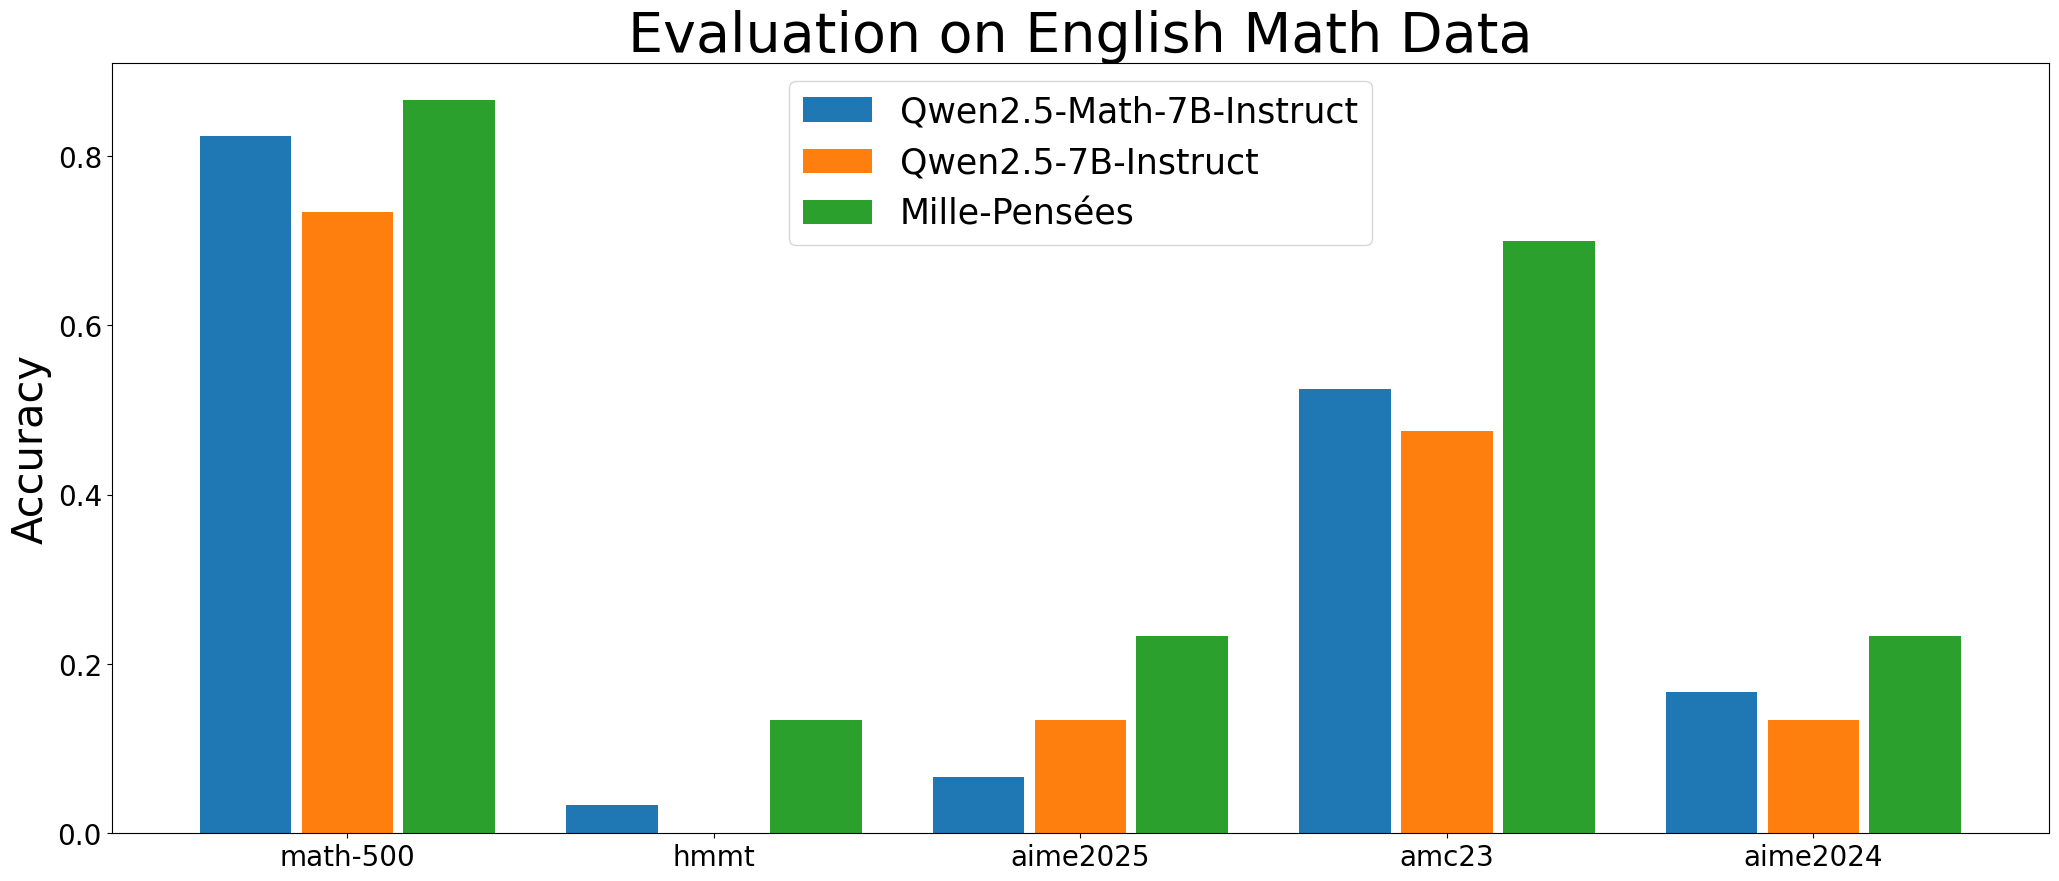

In [6]:
fig, ax = plt.subplots(figsize=(25,10))
for i, (model, result) in enumerate(results.items()):
    ax.bar(
        np.arange(len(datasets))*1.2 + (i-(0.5*(n_models-1)))/n_models,
        [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets],
        width=0.9/n_models,
        label=model.split("/")[-1]
    )

ax.set_xticks(np.arange(len(datasets))*1.2)
ax.set_xticklabels([dataset.replace("/","\n") for dataset in datasets], fontsize=20)

ax.set_yticks(np.arange(5)/5)
ax.set_yticklabels(np.arange(5)/5, fontsize=20)

ax.set_ylabel("Accuracy", fontsize=30)

ax.set_title("Evaluation on English Math Data", fontsize=40)
ax.legend(fontsize=25)
plt.savefig("accuracy.png")
plt.show()

FM - Getting Config: fasttext math
FM - Loading Model: facebook/fasttext-language-identification


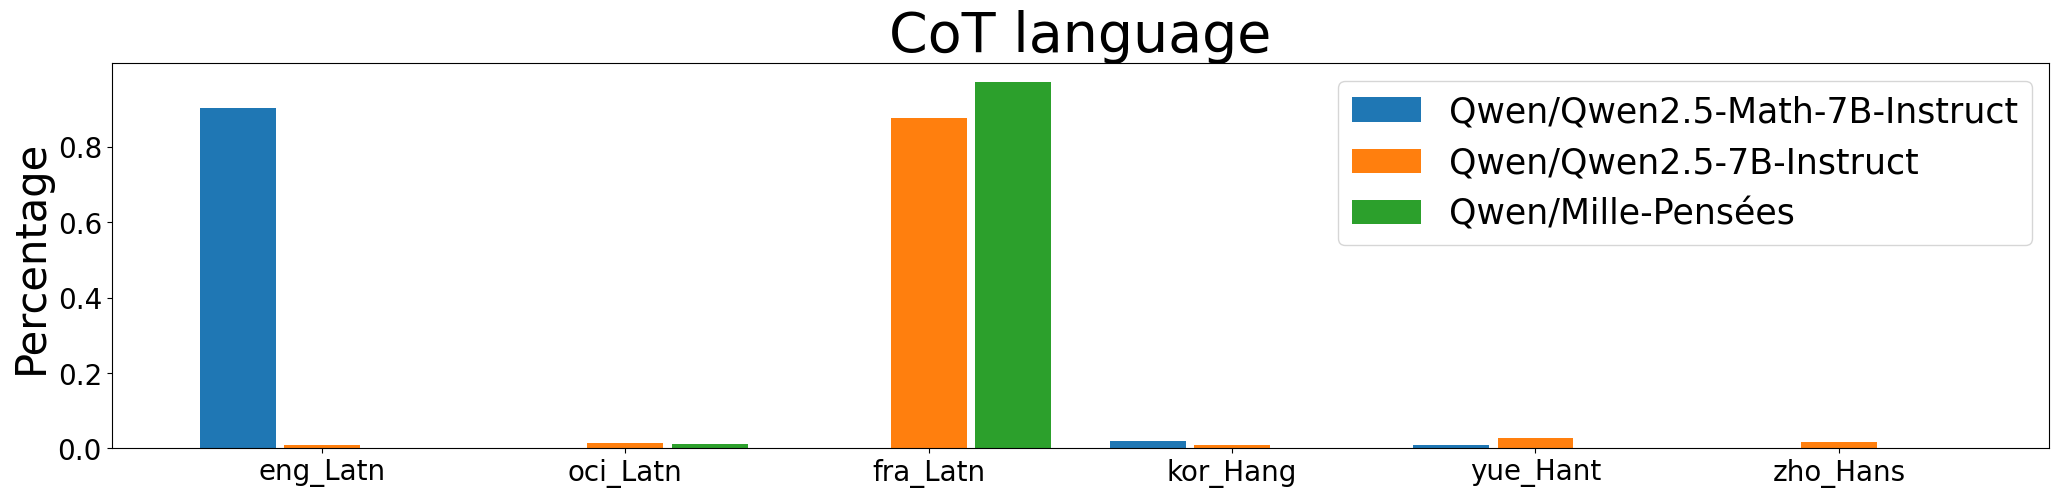

In [6]:
model_path, _, _ = get_config("fasttext")
classifier = load_model(model_path)

fig, ax = plt.subplots(figsize=(25,5))

top_languages = {}
for i, (model, result) in enumerate(results.items()):
    languages = {}
    top_languages_model = {}
    for dataset in datasets:
        languages_dataset = {}
        for sample in result["samples"][dataset]:
            lang_pred = classifier.predict(sample["generation"].replace("\n", " "), k=3)
            for lang, prob in zip(lang_pred[0], lang_pred[1]):
                lang = lang.split("__label__")[1]
                if lang in languages_dataset:
                    languages_dataset[lang] += prob
                else:
                    languages_dataset[lang] = prob
                if lang in languages:
                    languages[lang] += prob
                else:
                    languages[lang] = prob
        for lang in languages_dataset.keys():
            languages_dataset[lang] = languages_dataset[lang] / len(result["samples"][dataset])
    for lang in languages.keys():
        languages[lang] = languages[lang] / sum([len(result["samples"][dataset]) for dataset in datasets])
        if languages[lang] > 0.005:
            top_languages_model[lang] = languages[lang]

    top_languages[model] = top_languages_model

all_languages = list(set([language for top_languages_model in top_languages.values() for language in top_languages_model.keys()]))
for i, (model, result) in enumerate(results.items()):
    top_languages_model = [top_languages[model].get(language, 0) for language in all_languages]
    ax.bar(
        np.arange(len(top_languages_model))*1.2 + (i-(0.5*(n_models-1)))/n_models,
        list(top_languages_model),
        width=0.9/n_models,
        label=model
    )

ax.set_xticks(np.arange(len(all_languages))*1.2)
ax.set_xticklabels(all_languages, fontsize=20)

ax.set_yticks(np.arange(5)/5)
ax.set_yticklabels(np.arange(5)/5, fontsize=20)

ax.set_ylabel("Percentage", fontsize=30)
ax.set_title("CoT language", fontsize=40)
ax.legend(fontsize=25)
plt.savefig("language.png")
plt.show()

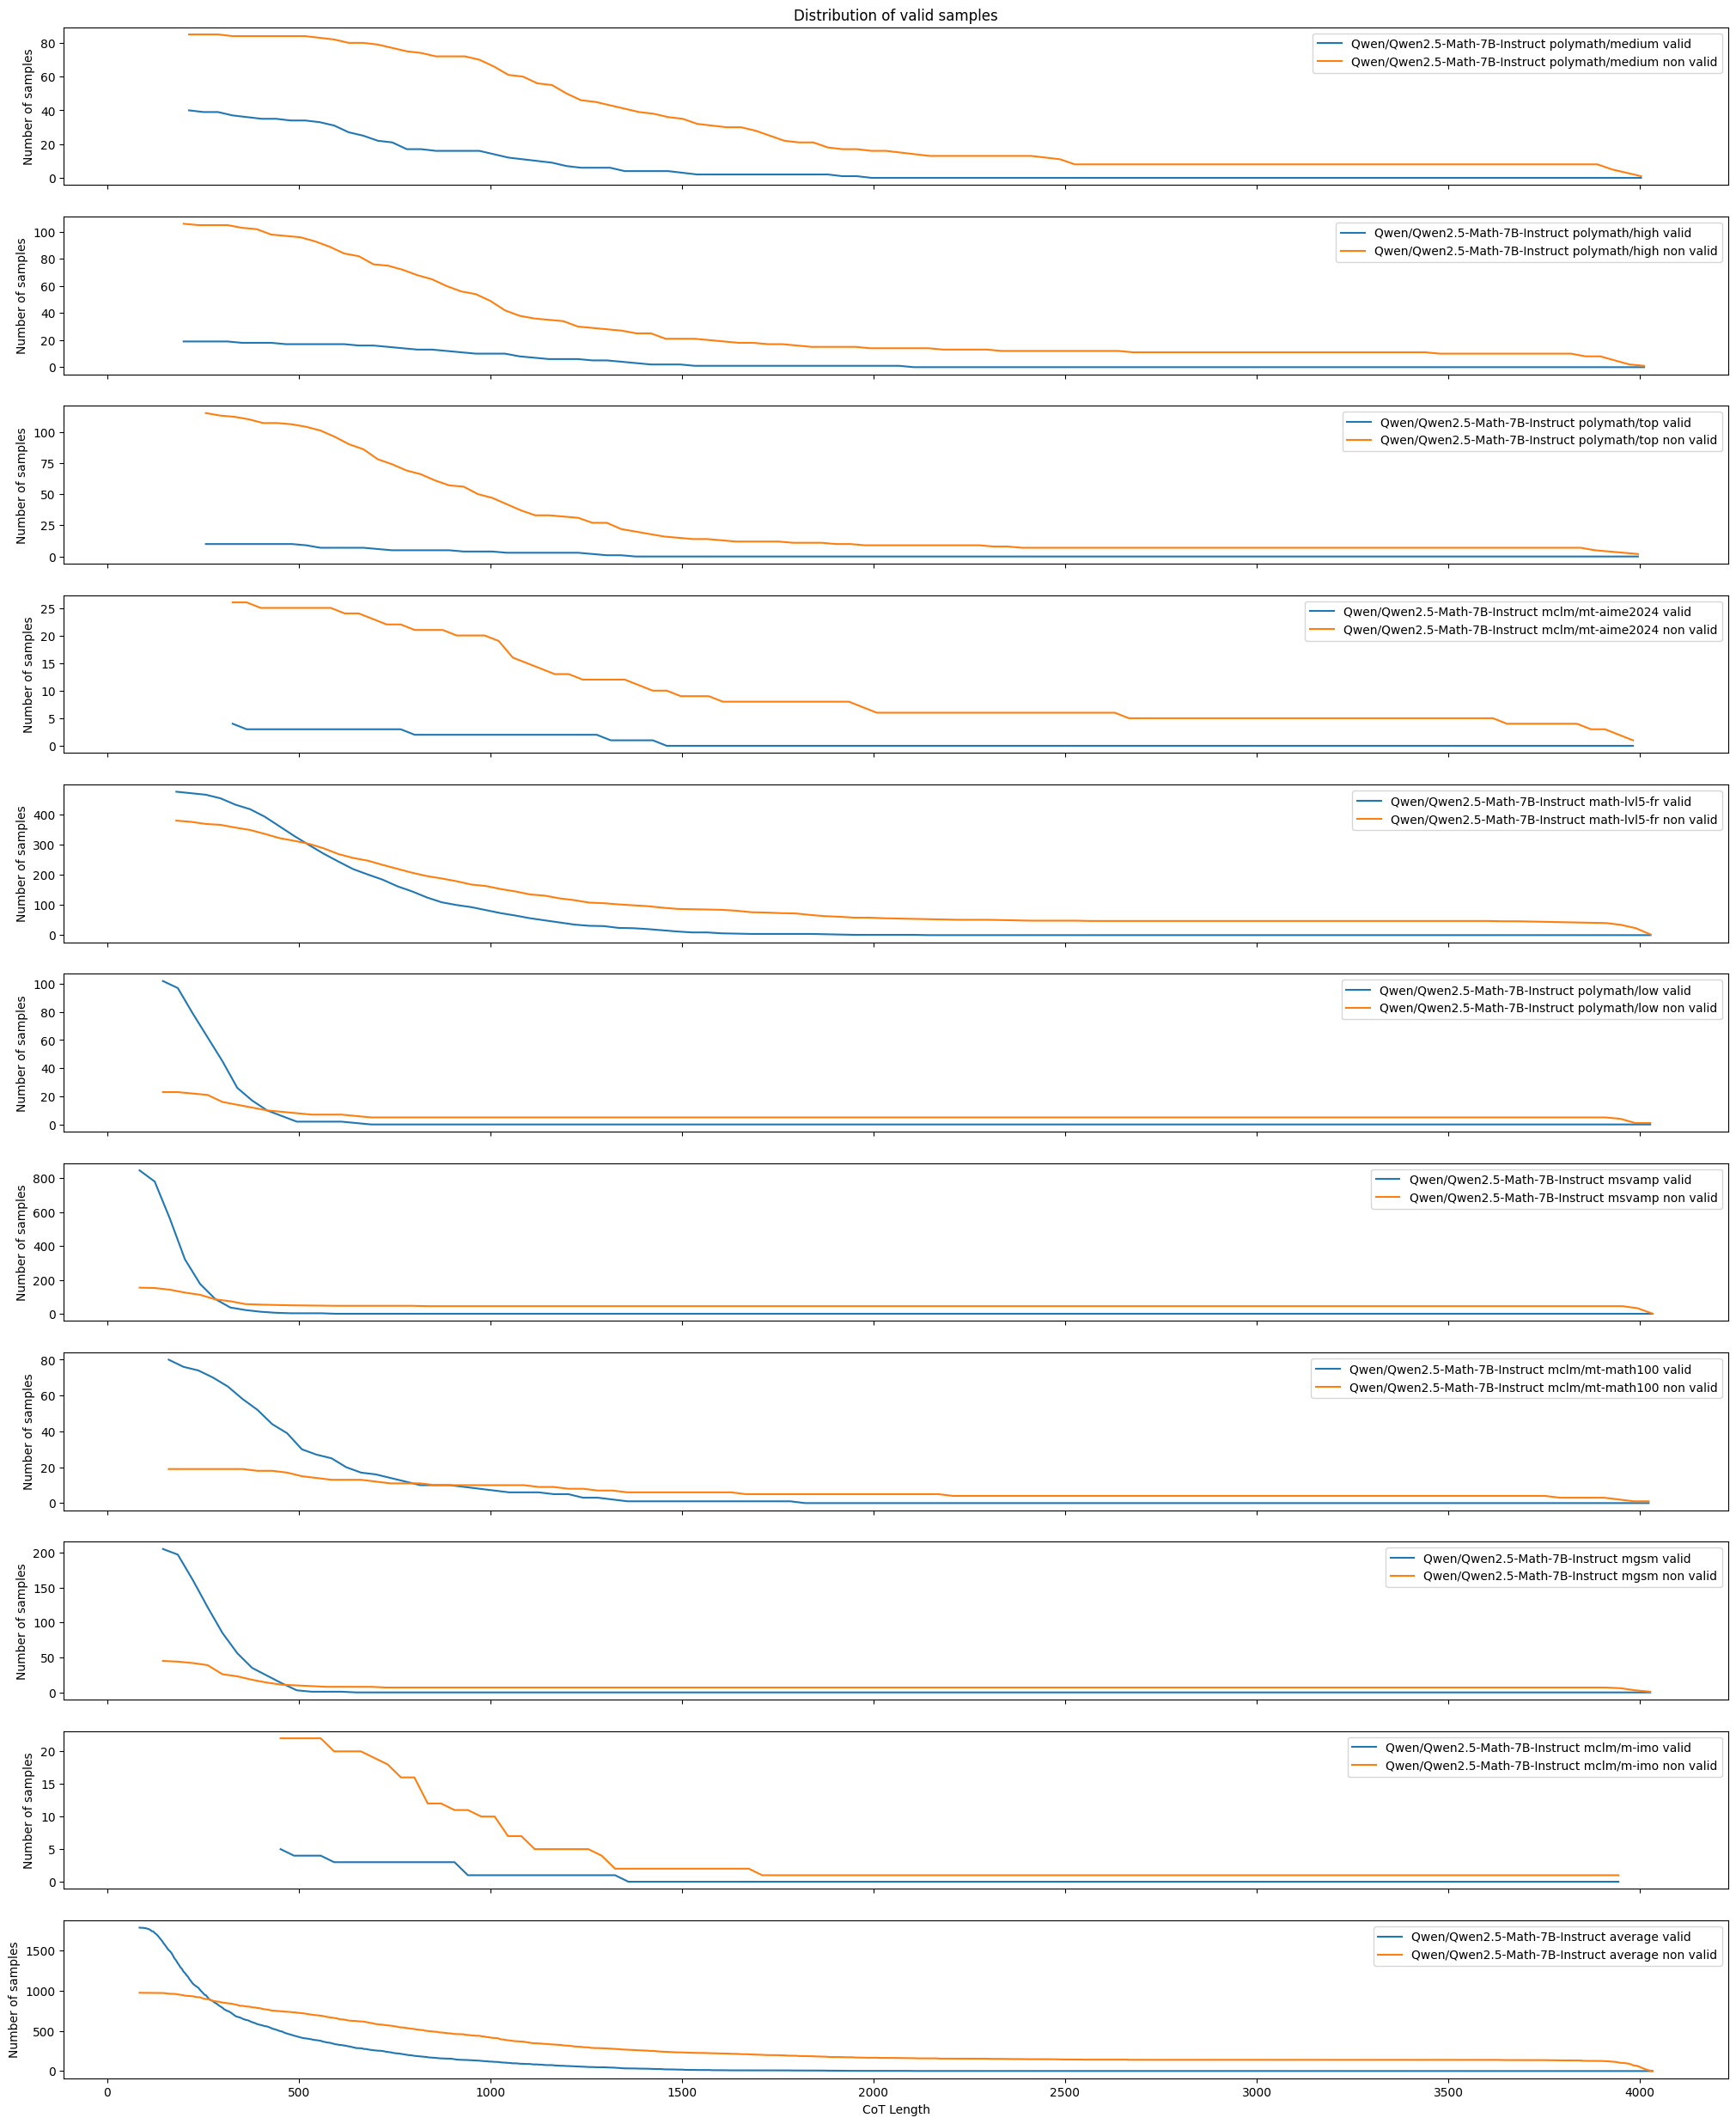

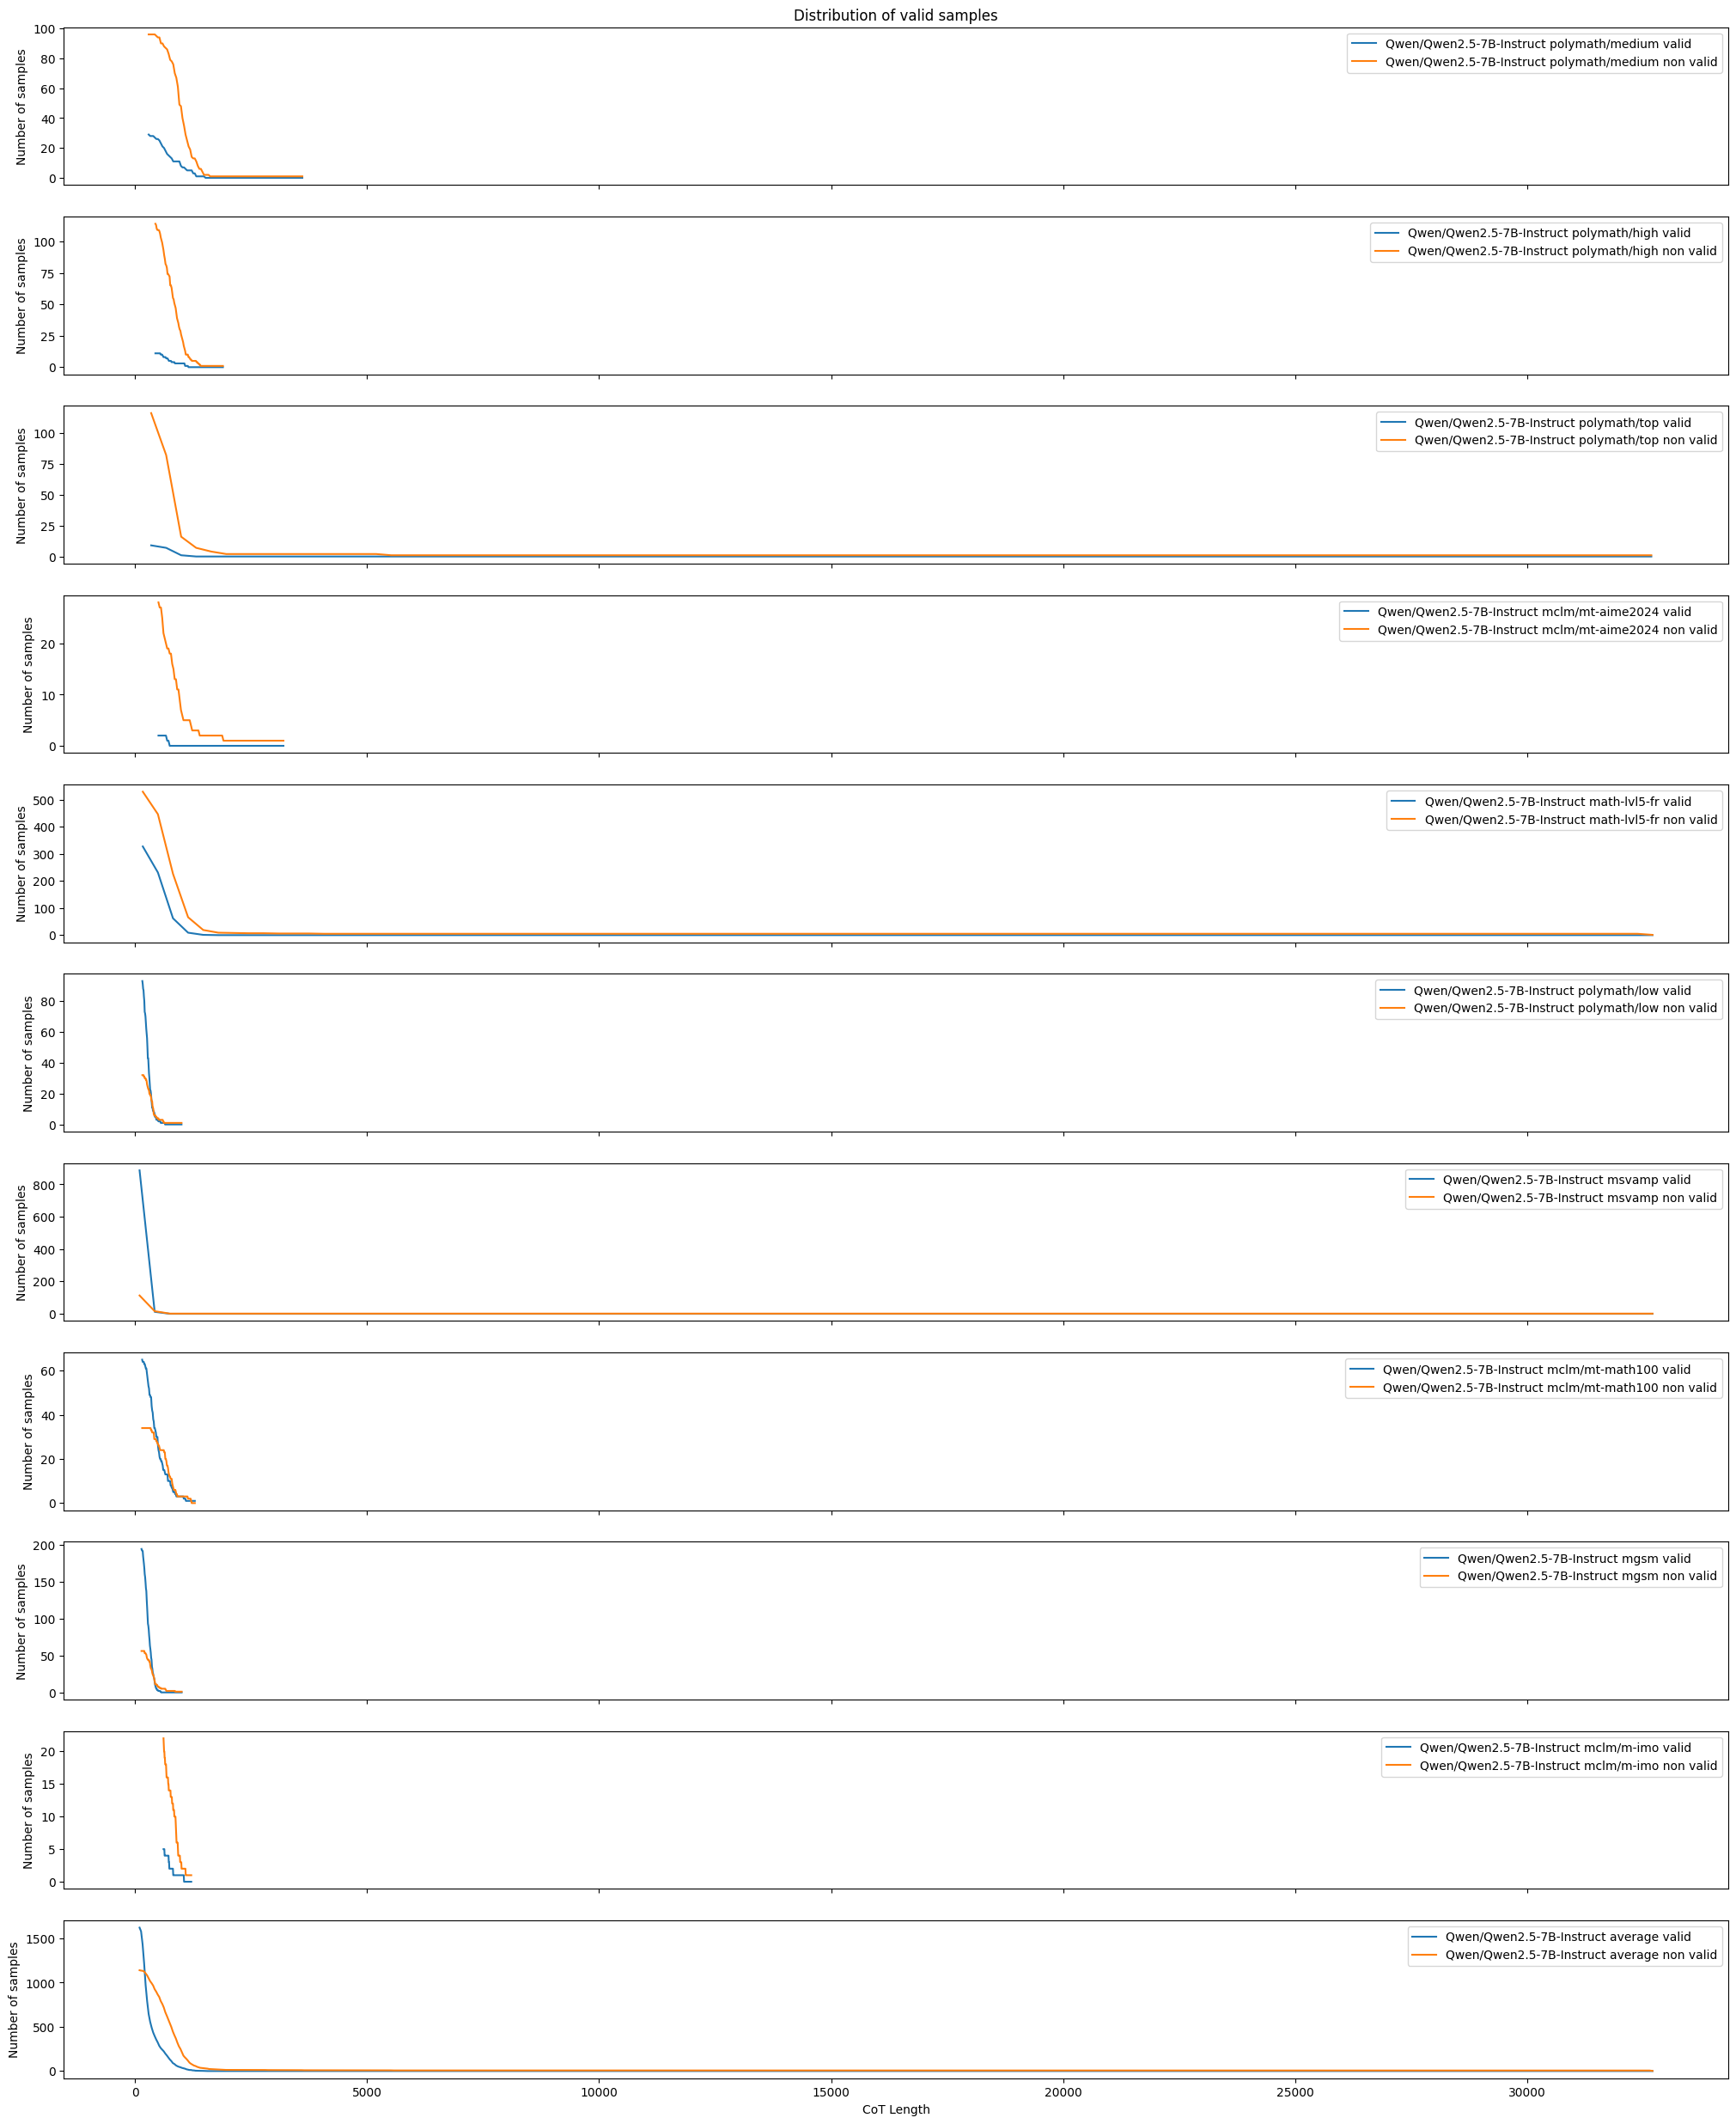

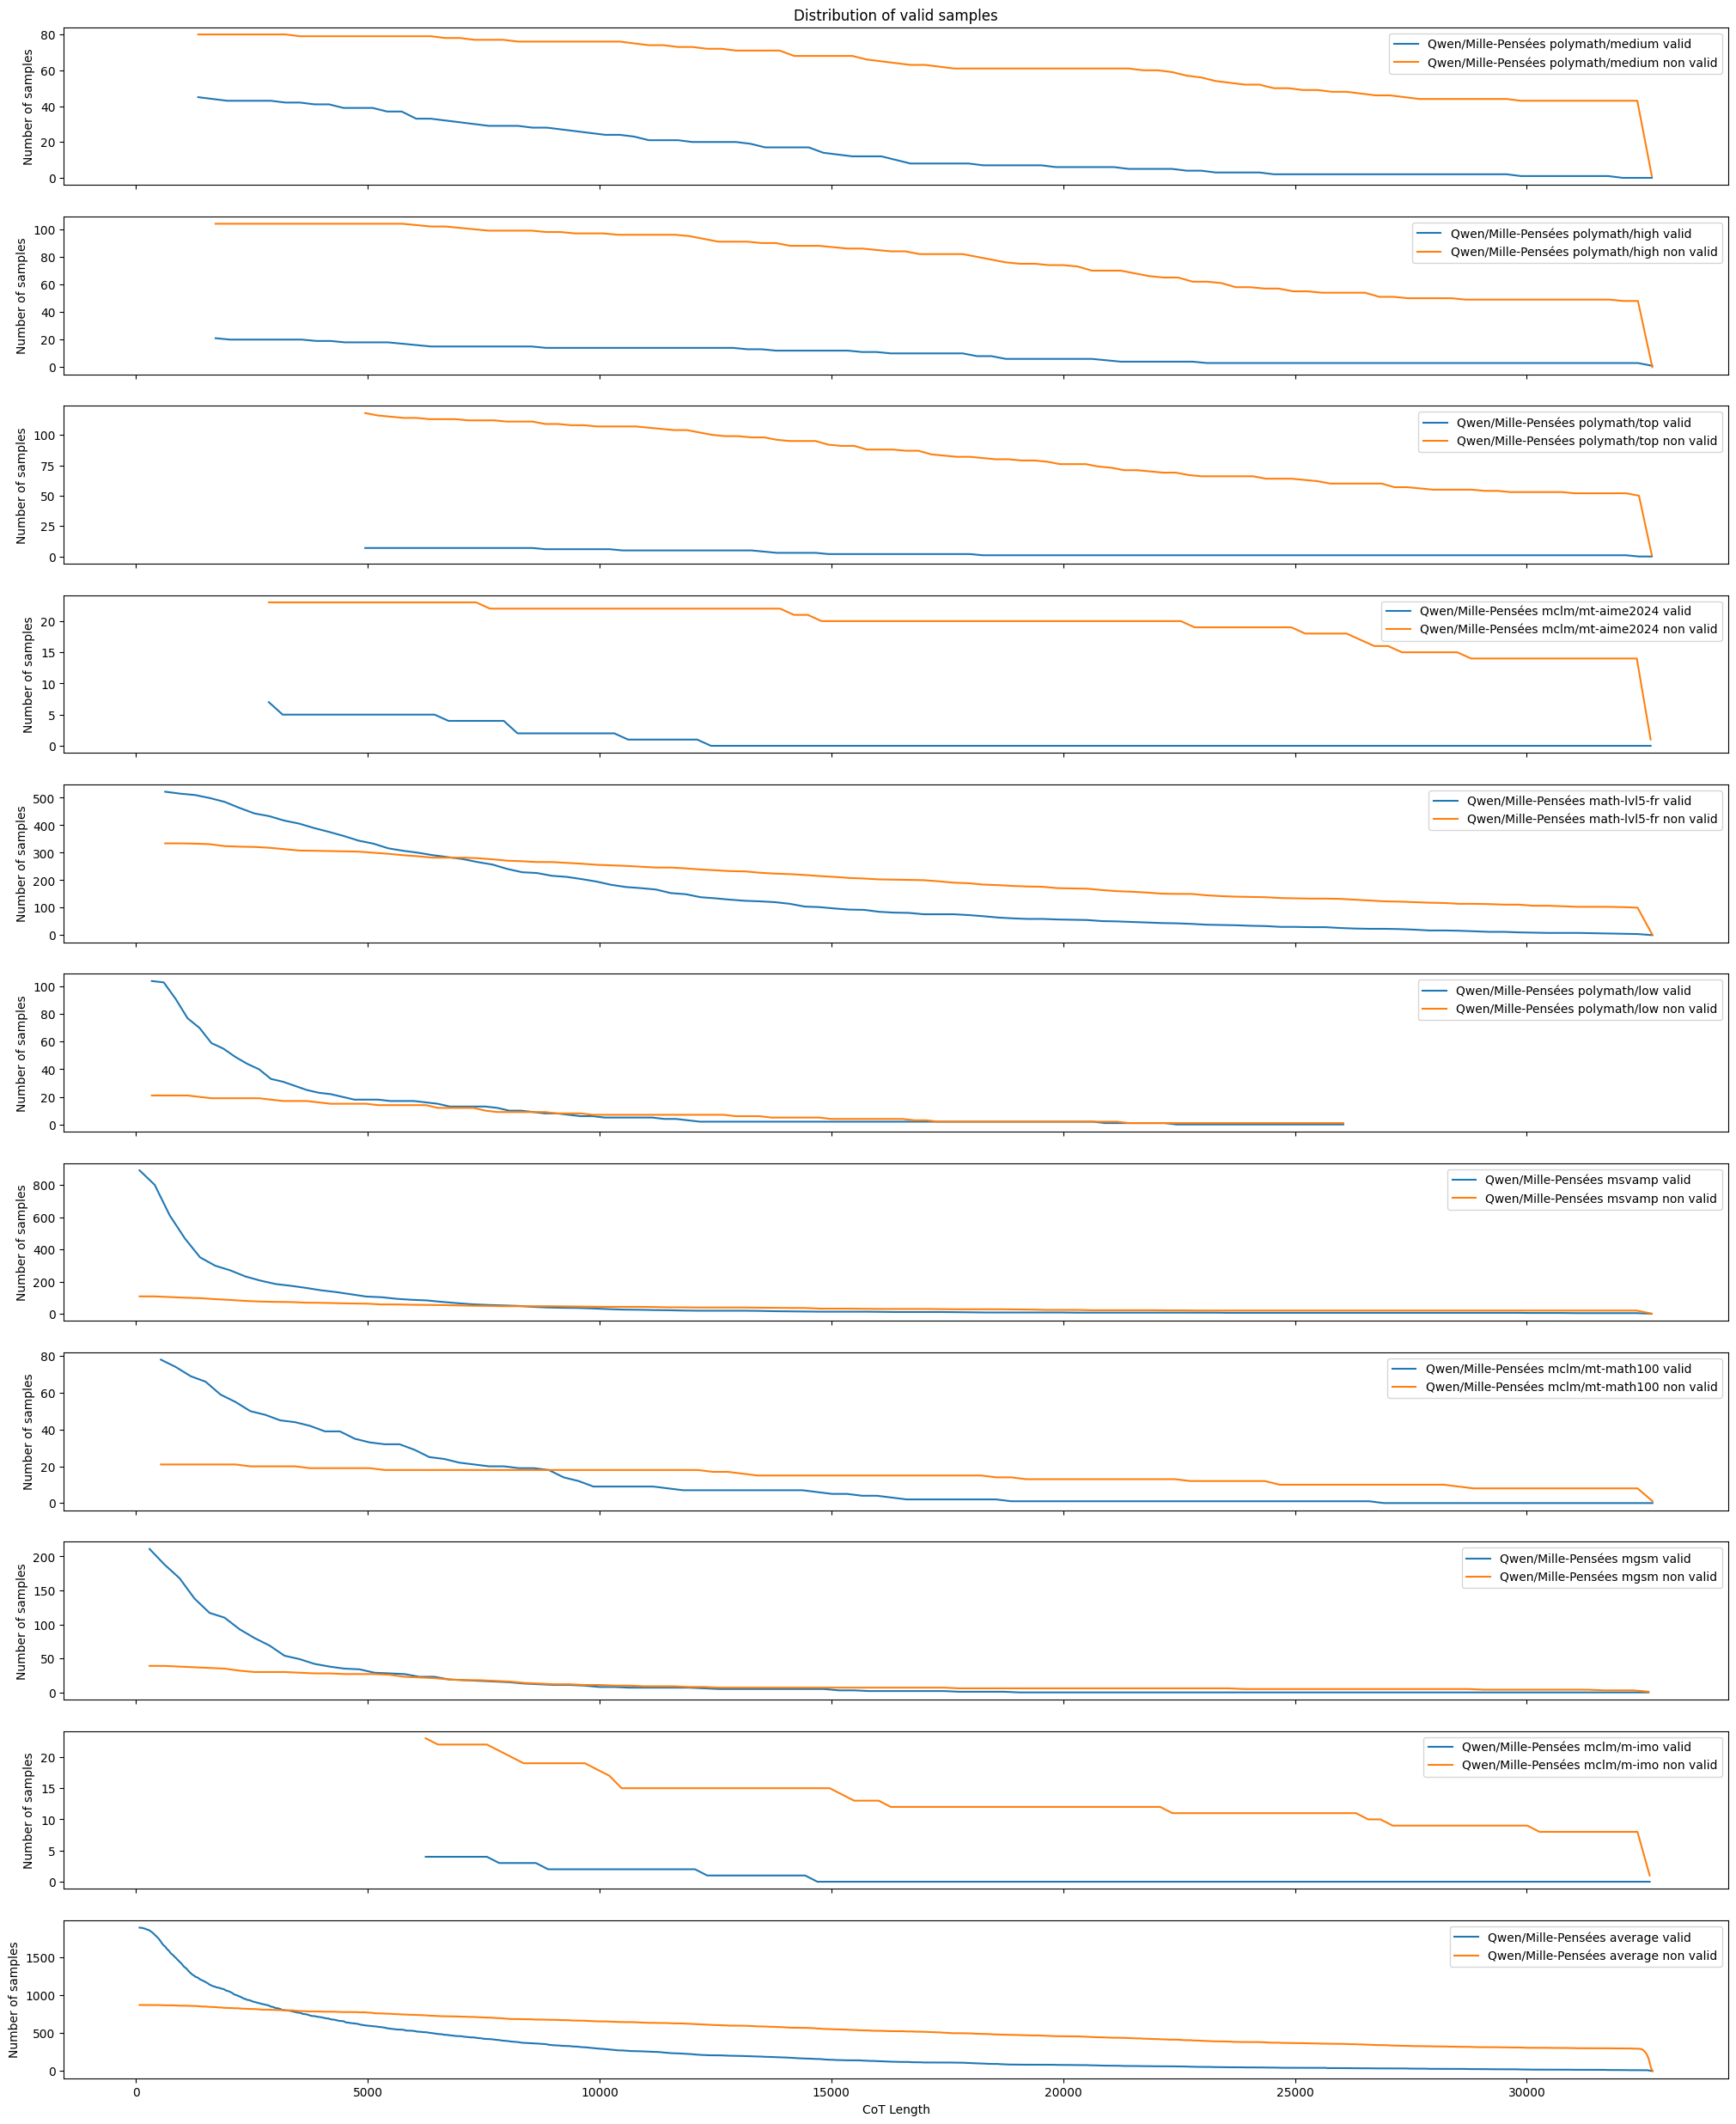

In [8]:
for model, result in results.items():
    fig, axs = plt.subplots(len(datasets)+1, figsize=(25,3*len(datasets)+1), sharex=True)
    axs[0].set_title("Distribution of valid samples")
    for i, dataset in enumerate(datasets):
        valid = []
        non_valid = []
        bins = np.histogram(
            [x["cot_length"] for x in result["samples"][dataset]],
            bins=100
        )[1]
        for x1, x2 in zip(bins, bins + [100000]):
            subset = [x["is_valid"] for x in result["samples"][dataset] if (x["cot_length"] >= x1 and x["cot_length"] < x2)]
            valid.append(sum(subset))
            non_valid.append(len(subset)-sum(subset))
        axs[i].plot(bins, valid, label=model+" "+dataset+" valid")
        axs[i].plot(bins, non_valid, label=model+" "+dataset+" non valid")
        axs[i].set_ylabel("Number of samples")
        axs[i].legend()
        
    bins = np.histogram(
        [x["cot_length"] for dataset_result in result["samples"].values() for x in dataset_result],
        bins=1000
    )[1]
    valid = []
    non_valid = []
    for x1, x2 in zip(bins, bins + [500000]):
        subset = [x["is_valid"] for dataset_result in result["samples"].values() for x in dataset_result if (x["cot_length"] >= x1 and x["cot_length"] < x2)]
        valid.append(sum(subset))
        non_valid.append(len(subset)-sum(subset))
    axs[-1].plot(bins, valid, label=model+" average valid")
    axs[-1].plot(bins, non_valid, label=model+" average non valid")
    axs[-1].set_xlabel("CoT Length")
    axs[-1].set_ylabel("Number of samples")
    axs[-1].legend()
    plt.savefig("valid.png")
    plt.show()
    

In [10]:
n_models=3
# datasets=["IFEval", "BBH", "GPQA", "MuSR", "MMLU-Pro"]
datasets=["BBH", "MuSR", "MMLU-Pro", "Hellaswag"]
# datasets=["BBH", "GPQA", "MuSR", "MMLU-Pro"]

results = {
    "Qwen2.5-Math-7B-Instruct": {
        "accuracies": {
            # "IFEval": 0.3345,
            "BBH": 0.4579,
            # "GPQA": 0.,
            "MuSR": 0.3889,
            "MMLU-Pro": 0.2901,
            "Hellaswag": 0.4394,
            # "avg": 0.
        }
    },
    "Qwen2.5-7B-Instruct" : {
        "accuracies": {
            # "IFEval": 0.7170,
            "BBH": 0.5504,
            # "GPQA": 0.3138,
            "MuSR": 0.4299,
            "MMLU-Pro": 0.4466,
            "Hellaswag": 0.6204,
            # "avg": 0.49154
        }
    },
    "Mille-Pensées": {
        "accuracies": {
            # "IFEval": 0.4796,
            "BBH": 0.5319,
            # "GPQA": 0.3272,
            "MuSR": 0.4246,
            "MMLU-Pro": 0.4173,
            "Hellaswag": 0.6053,
            # "avg": 0.43612
        }
    },
}

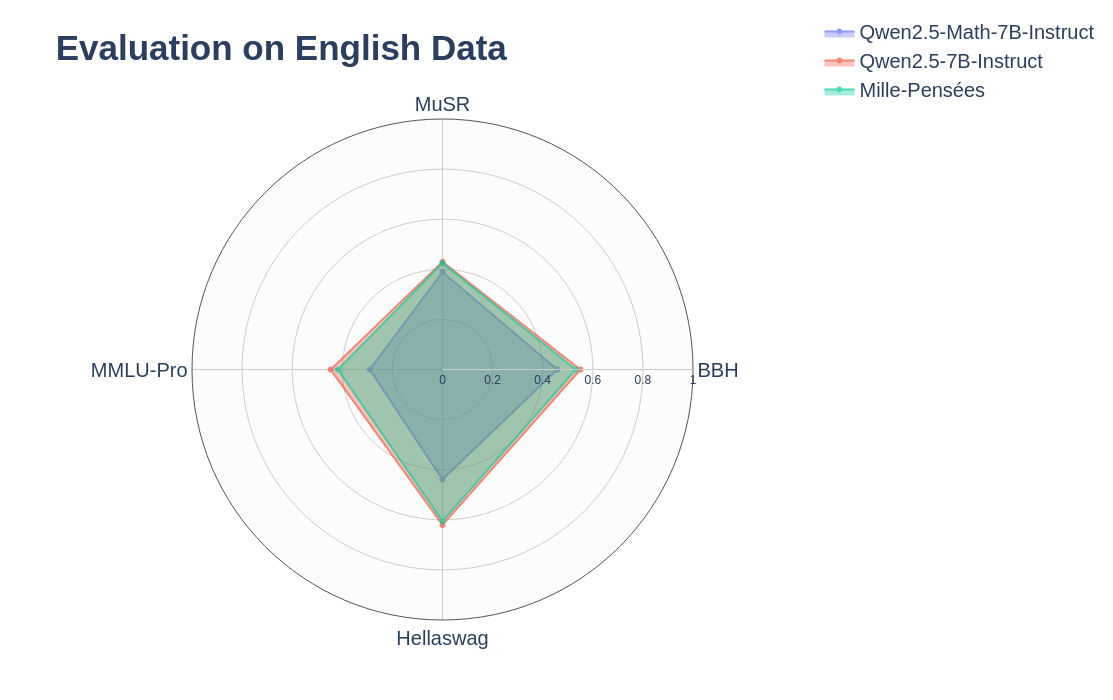

In [11]:
import plotly.graph_objects as go


fig = go.Figure()
for i, (model, result) in enumerate(results.items()):
    r = [result["accuracies"][dataset] if dataset in result["accuracies"] else 0.0 for dataset in datasets]
    r = list(r) + list([r[0]])
    fig.add_trace(go.Scatterpolar(
          r=r,
          theta=datasets + [datasets[0]],
        fill='toself',
          opacity=0.7,
          name=model.split("/")[-1]
    ))

fig.update_layout(
    width=1100,
    height=700,
    title="Evaluation on English Data",
    title_font_size=35,
    title_font_weight=1000,
    legend_font_size=20,
    legend_y=5000,
    legend_x=1000,
    polar=dict(
        bgcolor="#fcfcfc",
        angularaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#555",
            tickfont_size=20,
        ),
        radialaxis=dict(
            gridcolor="#ccc",
            tickcolor="#ccc",
            linecolor="#ccc",
            visible=True,
            range=[0, 1]
        )),
    showlegend=True
)

fig.show()